## Establecer conexión con Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importar librerías

In [15]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

## Acceso a archivo
Se establecen pasos de control adicional, como trabajar con una carpeta temporal para no hacer cambios en la original de dirve.

In [5]:
# RUTAS
RUTA_ORIGINAL_DRIVE = "/content/drive/MyDrive/train"  # Tu carpeta sagrada en Drive
RUTA_TRABAJO = "/content/train_temp"                  # Carpeta temporal en Colab+

print("Paso de Seguridad: Iniciando copia de archivos...")
print(f"Origen: {RUTA_ORIGINAL_DRIVE}")
print(f"Destino: {RUTA_TRABAJO}")

# Verificamos si ya existe la copia para no hacerlo dos veces
if not os.path.exists(RUTA_TRABAJO):
    # Copiamos todo el árbol de directorios
    shutil.copytree(RUTA_ORIGINAL_DRIVE, RUTA_TRABAJO)
    print("✅ ¡Copia completada! Tus archivos originales están a salvo.")
    print("Ahora trabajaremos exclusivamente sobre la copia temporal.")
else:
    print("ℹ️ La carpeta temporal ya existe. Saltando copia.")

# A partir de ahora, nuestra variable 'ruta_train' apunta a la copia, no al Drive.
ruta_train = RUTA_TRABAJO

Paso de Seguridad: Iniciando copia de archivos...
Origen: /content/drive/MyDrive/train
Destino: /content/train_temp
✅ ¡Copia completada! Tus archivos originales están a salvo.
Ahora trabajaremos EXCLUSIVAMENTE sobre la copia temporal.


## Visualización de imagenes

In [7]:
imagenes = os.listdir(ruta_train)
imagenes_perros = [img for img in imagenes if img.startswith("dog")][:9]
imagenes_gatos  = [img for img in imagenes if img.startswith("cat")][:9]


### Perros

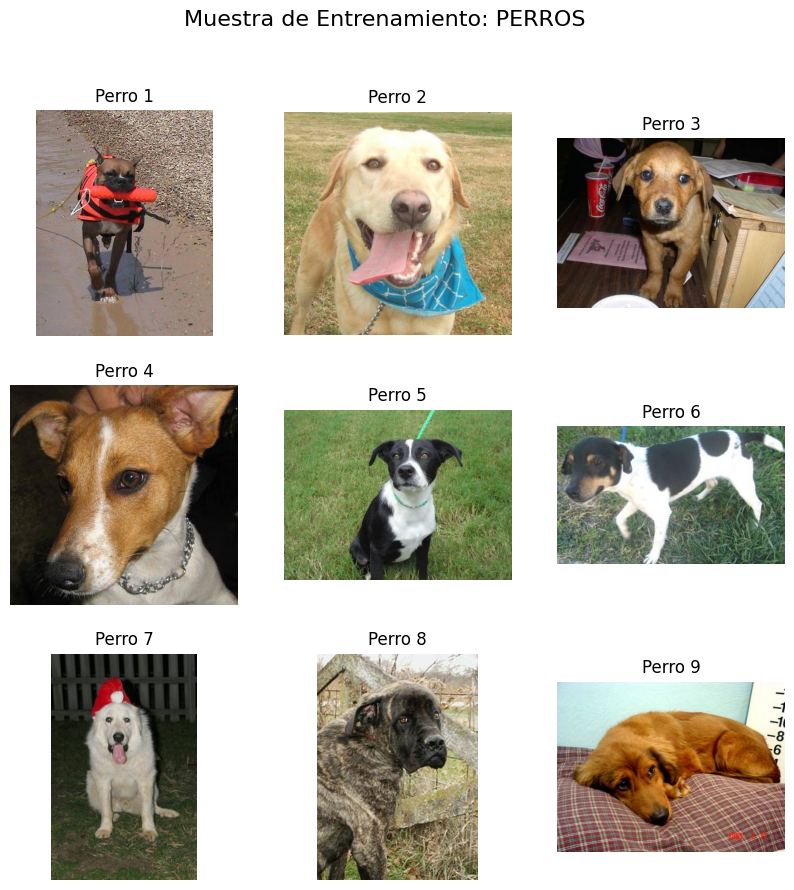

In [8]:
plt.figure(figsize=(10, 10)) # Tamaño del cuadro general

for i, nombre_imagen in enumerate(imagenes_perros):
    # 1. Construir ruta
    img_path = os.path.join(ruta_train, nombre_imagen)
    imagen = mpimg.imread(img_path)

    # 2. Crear el sub-gráfico (3 filas, 3 columnas, posición i+1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(f"Perro {i+1}")
    plt.axis("off") # Quitar ejes para limpieza

plt.suptitle("Muestra de Entrenamiento: PERROS", fontsize=16)
plt.show()

### Gatos

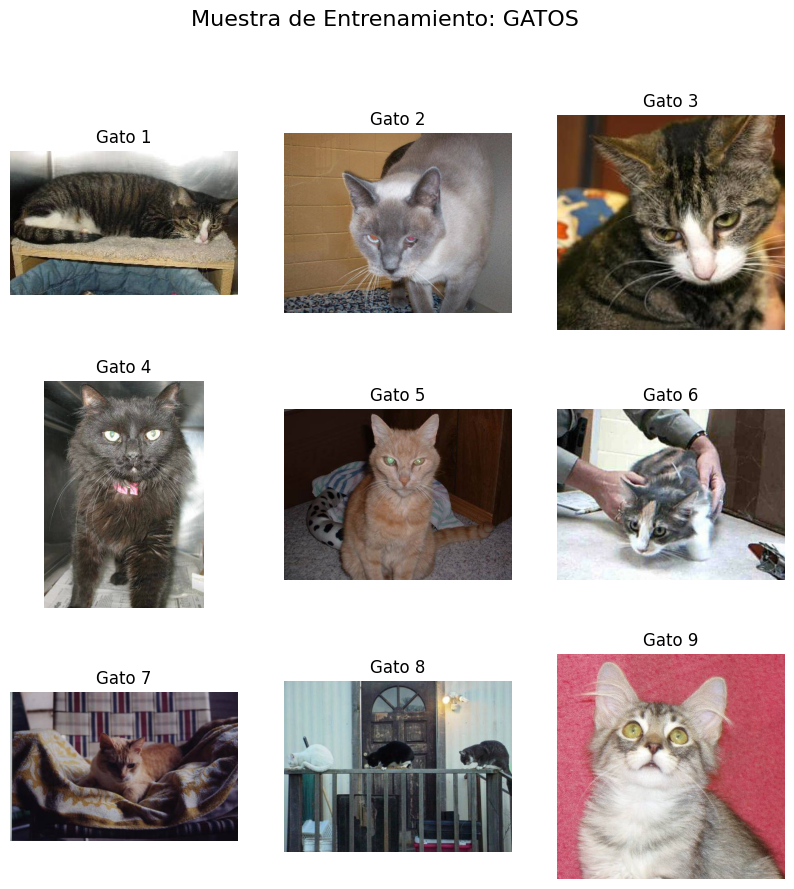

In [9]:
plt.figure(figsize=(10, 10)) # Nueva figura independiente

for i, nombre_imagen in enumerate(imagenes_gatos):
    # 1. Construir ruta
    img_path = os.path.join(ruta_train, nombre_imagen)
    imagen = mpimg.imread(img_path)

    # 2. Crear el sub-gráfico (3 filas, 3 columnas, posición i+1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(f"Gato {i+1}")
    plt.axis("off")

plt.suptitle("Muestra de Entrenamiento: GATOS", fontsize=16)
plt.show()

## Preprocesamiento y train/test

In [10]:
# Crear DataFrame con etiquetas
categorias = []
for archivo in imagenes:
    categoria = 'dog' if 'dog' in archivo else 'cat'
    categorias.append(categoria)

df = pd.DataFrame({
    'filename': imagenes,
    'category': categorias
})

# Dividir en Train y Test (Simulación de carpetas separadas)
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

# Crear Generador (Normalización y tamaño 200x200)
datagen = ImageDataGenerator(rescale=1./255)

print("\n--- GENERANDO FLUJOS DE DATOS ---")
trdata = datagen.flow_from_dataframe(
    train_df,
    ruta_train,
    x_col='filename',
    y_col='category',
    target_size=(200, 200),  # Requisito de la instrucción
    class_mode='categorical', # Para 2 neuronas de salida
    batch_size=32
)

tsdata = datagen.flow_from_dataframe(
    test_df,
    ruta_train,
    x_col='filename',
    y_col='category',
    target_size=(200, 200),
    class_mode='categorical',
    batch_size=32
)


--- GENERANDO FLUJOS DE DATOS ---
Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


## Construcción de RNA

In [11]:
print("\n--- CONSTRUYENDO MODELO (VGG16 Custom) ---")
model = Sequential()

# Bloque 1
model.add(Conv2D(input_shape=(200, 200, 3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 2
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 3
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 4
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 5
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Clasificador
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
# Salida corregida para coincidir con class_mode='categorical'
model.add(Dense(units=2, activation="softmax"))

# Compilación
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


--- CONSTRUYENDO MODELO (VGG16 Custom) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

## Añadir elementos restantes

In [12]:
# Definimos el optimizador Adam con un learning rate bajo (recomendado para VGG)
opt = Adam(learning_rate=0.0001)

# Compilamos: Definimos cómo aprende el modelo
# 'categorical_crossentropy' es obligatorio porque usamos 2 neuronas con softmax
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("Modelo compilado. Iniciando entrenamiento...")

Modelo compilado. Iniciando entrenamiento...


In [13]:
# ENTRENAR EL MODELO
# Guardamos el proceso en la variable 'historial' para medir rendimiento luego
historial = model.fit(
    trdata,
    steps_per_epoch=trdata.samples // 32,
    epochs=5,  # El número depende de los recursos
    validation_data=tsdata,
    validation_steps=tsdata.samples // 32
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 359s 505ms/step - accuracy: 0.5742 - loss: 0.6607 - val_accuracy: 0.6562 - val_loss: 0.6182
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - accuracy: 0.6988 - loss: 0.5660 - val_accuracy: 0.7736 - val_loss: 0.4540
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - accuracy: 0.7856 - loss: 0.4300 - val_accuracy: 0.8391 - val_loss: 0.3596
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - accuracy: 0.8532 - loss: 0.3233 - val_accuracy: 0.8678 - val_loss: 0.2919
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - accuracy: 0.8871 - loss: 0.2603 - val_accuracy: 0.8944 - val_loss: 0.2431


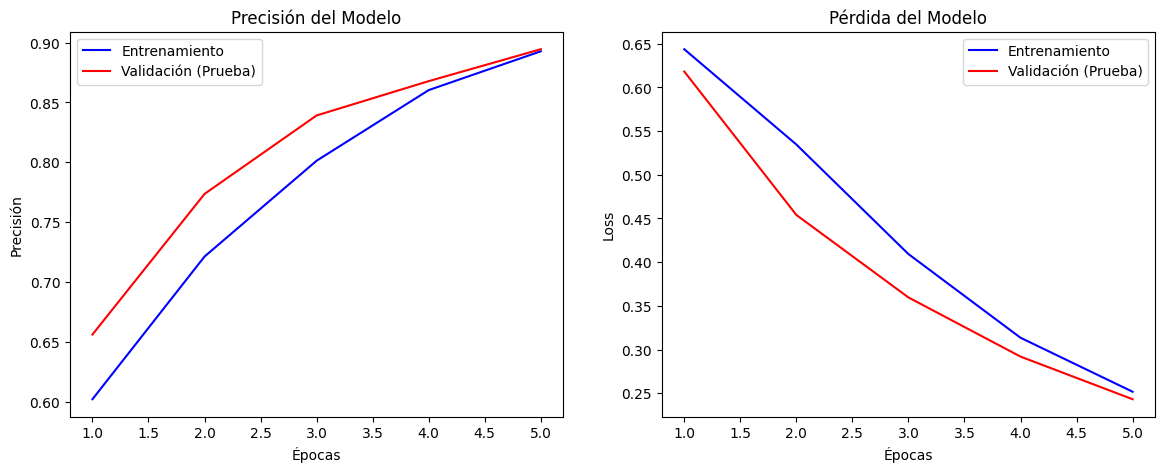

In [14]:
# MEDIR SU RENDIMIENTO (Gráficos)
# Extraemos los datos del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epochs = range(1, len(acc) + 1)

# Creamos una figura con dos gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Entrenamiento')
plt.plot(epochs, val_acc, 'r', label='Validación (Prueba)')
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfico 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Entrenamiento')
plt.plot(epochs, val_loss, 'r', label='Validación (Prueba)')
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Configuración de Callbacks y entrenamiento

In [16]:
# 1. Definir el ModelCheckpoint
# Se guarda el modelo en un archivo "vgg16_best.h5" solo cuando la precisión en validación mejora.
checkpoint = ModelCheckpoint(
    "vgg16_best.h5",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)
# 2. Definir el EarlyStopping
# Detiene el entrenamiento si la precisión no mejora después de 5 épocas (patience).
early = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0,
    patience=5,
    verbose=1,
    mode='auto'
)

# 3. Entrenar con los Callbacks (fit reemplaza a fit_generator en versiones nuevas)
print("--- Iniciando entrenamiento inteligente ---")
historial = model.fit(
    trdata,
    steps_per_epoch=trdata.samples // 32,
    epochs=10,  # Ponemos más épocas, EarlyStopping lo parará si es necesario
    validation_data=tsdata,
    validation_steps=tsdata.samples // 32,
    callbacks=[checkpoint, early] # Se pasan callbacks
)

--- Iniciando entrenamiento inteligente ---
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9186 - loss: 0.1998
Epoch 1: val_accuracy improved from -inf to 0.90745, saving model to vgg16_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 317s 507ms/step - accuracy: 0.9186 - loss: 0.1998 - val_accuracy: 0.9075 - val_loss: 0.2242
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9307 - loss: 0.1637
Epoch 2: val_accuracy improved from 0.90745 to 0.91446, saving model to vgg16_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 316s 506ms/step - accuracy: 0.9307 - loss: 0.1637 - val_accuracy: 0.9145 - val_loss: 0.2109
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9439 - loss: 0.1351
Epoch 3: val_accuracy improved from 0.91446 to 0.93209, saving model to vgg16_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 315s 504ms/step - accuracy: 0.9439 - loss: 0.1351 - val_accuracy: 0.9321 - val_loss: 0.1696
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9573 - loss: 0.1065
Epoch 4: val_accuracy did not improve from 0.93209
625/625 ━━━━━━━━━━━━━━━━━━━━ 303s 485ms/step - accuracy: 0.9573 - loss: 0.1065 - val_accuracy: 0.9271 - val_loss: 0.1697
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9641 - loss: 0.0887
Epoch 5: val_accuracy improved from 0.93209 to 0.93289, saving model to vgg16_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 315s 504ms/step - accuracy: 0.9641 - loss: 0.0887 - val_accuracy: 0.9329 - val_loss: 0.1603
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9720 - loss: 0.0687
Epoch 6: val_accuracy did not improve from 0.93289
625/625 ━━━━━━━━━━━━━━━━━━━━ 303s 485ms/step - accuracy: 0.9720 - loss: 0.0687 - val_accuracy: 0.9327 - val_loss: 0.1576
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9748 - loss: 0.0657
Epoch 7: val_accuracy did not improve from 0.93289
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 484ms/step - accuracy: 0.9748 - loss: 0.0657 - val_accuracy: 0.9197 - val_loss: 0.2121
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9798 - loss: 0.0536
Epoch 8: val_accuracy did not improve from 0.93289
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 484ms/step - accuracy: 0.9798 - loss: 0.0536 - val_accuracy: 0.9251 - val_loss: 0.2000
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9830 - loss: 0.0437
Epoch 9: va

625/625 ━━━━━━━━━━━━━━━━━━━━ 335s 536ms/step - accuracy: 0.9861 - loss: 0.0379 - val_accuracy: 0.9395 - val_loss: 0.2359


## Testeo


--- Cargando el mejor modelo guardado ---


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


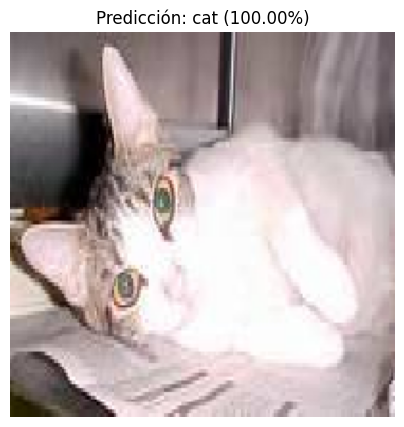

Etiquetas disponibles: {'cat': 0, 'dog': 1}
Valor crudo de predicción: [1.0000000e+00 6.7611733e-10]


In [17]:
# Cargar el mejor modelo guardado
print("\n--- Cargando el mejor modelo guardado ---")
best_model = load_model("vgg16_best.h5")

# Hacer predicciones con el conjunto de test
# Tomamos un lote de imágenes del generador de prueba
imagenes_test, etiquetas_reales = next(tsdata)

# Hacemos la predicción sobre este lote
predicciones = best_model.predict(imagenes_test)

# Vamos a ver la primera imagen del lote y qué dice el modelo
plt.figure(figsize=(5,5))
plt.imshow(imagenes_test[0])
plt.axis('off')

# Interpretación (0 es Gato, 1 es Perro - depende del orden alfabético que usó el generador)
# Como usamos 'categorical', la predicción es un array ej: [0.1, 0.9] -> Perro
clase_predicha = np.argmax(predicciones[0])
confianza = np.max(predicciones[0]) * 100

# Obtenemos las etiquetas reales del generador
labels = {v: k for k, v in trdata.class_indices.items()}
nombre_prediccion = labels[clase_predicha]

plt.title(f"Predicción: {nombre_prediccion} ({confianza:.2f}%)")
plt.show()

print("Etiquetas disponibles:", trdata.class_indices)
print(f"Valor crudo de predicción: {predicciones[0]}")